# Predicting California house prices

**Building and evaluating a linear regression model in sci-kit learn to predict the value of house prices in California.**

**Question:** What features are most strongly correlated to median house value, and given some of those features and their values, can you predict the median house value of a house in California by training a multiple linear regression model? Once the model is built, evaluate it and interpret its results. 

Dataset: [California Housing Prices Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices) (Kaggle), 20,640 rows, 10 columns.

# 1. Imports and loads

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
df = pd.read_csv('housing.csv')

## 2: data understanding

In [4]:
df.shape

(20640, 10)

In [5]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

I can see that every column in the dataset is numeric except for `ocean_proximity` which is a categorical data type. For it to be used in the linear regression model, I will have to one-hot encode it (convert it into binary 0 and 1 values for each category). 

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.sort_values('median_house_value', ascending=False).head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10667,-117.88,33.55,27.0,2278.0,316.0,772.0,304.0,10.1275,500001.0,<1H OCEAN
16916,-122.34,37.57,52.0,2635.0,408.0,967.0,374.0,7.0422,500001.0,NEAR OCEAN
16946,-122.33,37.55,33.0,2199.0,312.0,827.0,319.0,6.1349,500001.0,NEAR OCEAN
8877,-118.49,34.04,48.0,2381.0,345.0,859.0,306.0,8.0257,500001.0,<1H OCEAN
8878,-118.50,34.04,52.0,3000.0,374.0,1143.0,375.0,15.0001,500001.0,<1H OCEAN
8879,-118.50,34.04,52.0,2233.0,317.0,769.0,277.0,8.3839,500001.0,<1H OCEAN
16941,-122.34,37.55,44.0,2465.0,328.0,843.0,324.0,6.9533,500001.0,NEAR OCEAN
16940,-122.33,37.55,51.0,2565.0,332.0,870.0,309.0,9.3694,500001.0,NEAR OCEAN
16939,-122.32,37.55,50.0,2501.0,433.0,1050.0,410.0,4.6406,500001.0,NEAR OCEAN
16938,-122.33,37.56,50.0,1975.0,245.0,644.0,251.0,10.0743,500001.0,NEAR OCEAN


In [8]:
df.sort_values('median_house_value', ascending=False).tail(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2779,-114.65,32.79,21.0,44.0,33.0,64.0,27.0,0.8571,25000.0,INLAND
14326,-117.16,32.71,52.0,845.0,451.0,1230.0,375.0,1.0918,22500.0,NEAR OCEAN
16186,-121.29,37.95,52.0,107.0,79.0,167.0,53.0,0.7917,22500.0,INLAND
13889,-116.57,35.43,8.0,9975.0,1743.0,6835.0,1439.0,2.7138,22500.0,INLAND
1825,-122.32,37.93,33.0,296.0,73.0,216.0,63.0,2.6750,22500.0,NEAR BAY
5887,-118.33,34.15,39.0,493.0,168.0,259.0,138.0,2.3667,17500.0,<1H OCEAN
9188,-117.86,34.24,52.0,803.0,267.0,628.0,225.0,4.1932,14999.0,INLAND
2521,-122.74,39.71,16.0,255.0,73.0,85.0,38.0,1.6607,14999.0,INLAND
2799,-117.02,36.40,19.0,619.0,239.0,490.0,164.0,2.1000,14999.0,INLAND
19802,-123.17,40.31,36.0,98.0,28.0,18.0,8.0,0.5360,14999.0,INLAND


## 3: Data Preparation

In [9]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

207 NA's appear in the `total_bedrooms` column. I need to clean these otherwise they may affect the model.

In [10]:
df.loc[df['total_bedrooms'].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


Since `total_bedrooms` had only 207 missing values (~1% of the dataset) and the column is right-skewed (mean of 538 vs. median of 435), I imputed the missing values with the median, as it's more robust to outliers and better represents the typical value than the mean would.

In [11]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

Checking to see if there are any null values left:

In [12]:
df['total_bedrooms'].isna().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

Now, I want to investigate if there are outliers in the median house value column.

Text(0.5, 0, '')

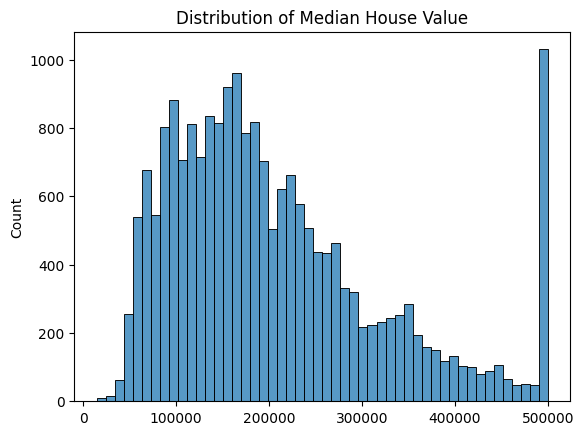

In [14]:
sns.histplot(data=df, x= 'median_house_value', bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('')

In [15]:
df_expensive_houses_extreme = df[df['median_house_value'] == 500001]
df_expensive_houses = df[df['median_house_value'] > 480000]
df_expensive_houses_extreme.shape

(965, 10)

In [16]:
df_expensive_houses.shape

(1079, 10)

In [17]:
df = df[df['median_house_value'] != 500001]

I decide to drop the rows where `median_house_value` = 500,001 because 965 houses are valued at $500,001, while 1079 houses are valued over $480,000. The weirdly large spike of houses at this top end valuation suggest that the dataset is capping prices at $500,001. 

## 4: Feature Understanding

In [18]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

I can see from the distribution above that only 5 houses are situated on an island. This is a very small sample, which will make it difficult for any model to reliably learn the effect of island location on `median_house_value`. This problem will be especially pronounced after a train/test split, when even fewer island samples remain to train or validate on.

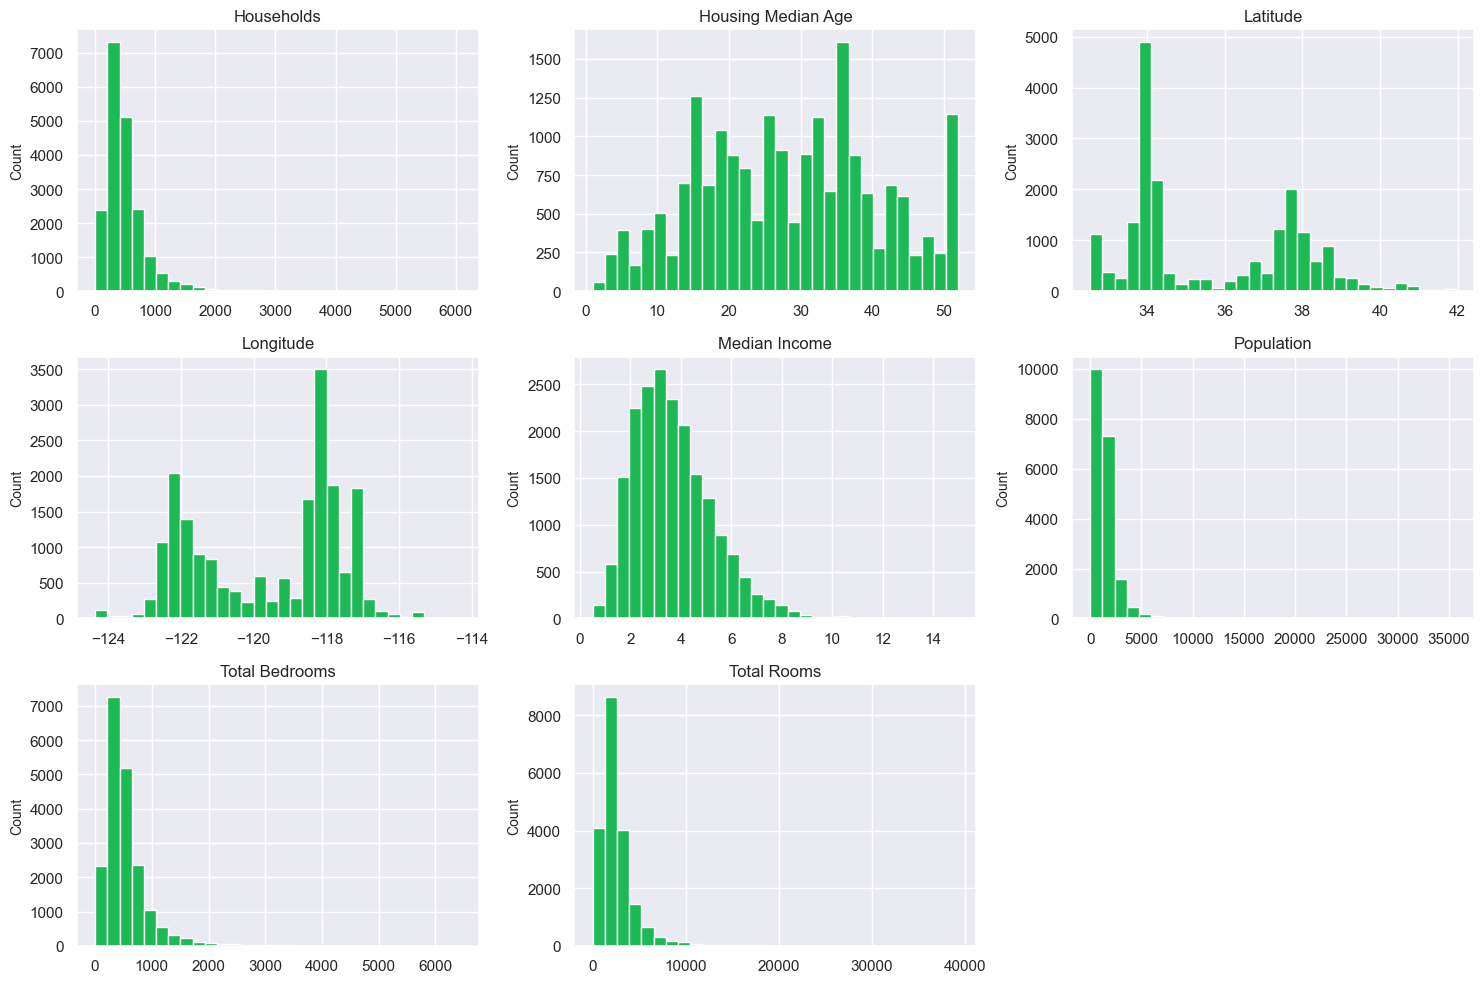

In [19]:
import math

sns.set_theme()  # applies seaborn's default grey/white-gridline look

exclude_cols = ['median_house_value']
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude_cols)

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='#1DB954', edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count', fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Feature Relationships

In [20]:
df.groupby('ocean_proximity')['median_house_value'].agg(['mean', 'count']).round(2).sort_values(by= 'mean', ascending= False)

,mean,count
ocean_proximity,,
ISLAND,380440.00,5
NEAR BAY,236925.57,2096
NEAR OCEAN,227716.80,2446
<1H OCEAN,224013.19,8604
INLAND,123252.62,6524


On average, houses on an island have the highest median value ($380,440), followed by houses near a bay ($236,925). Inland houses have the lowest median house value on average ($123,253).

In [21]:
df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [22]:
house_price_features = ['latitude', 'longitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', ]

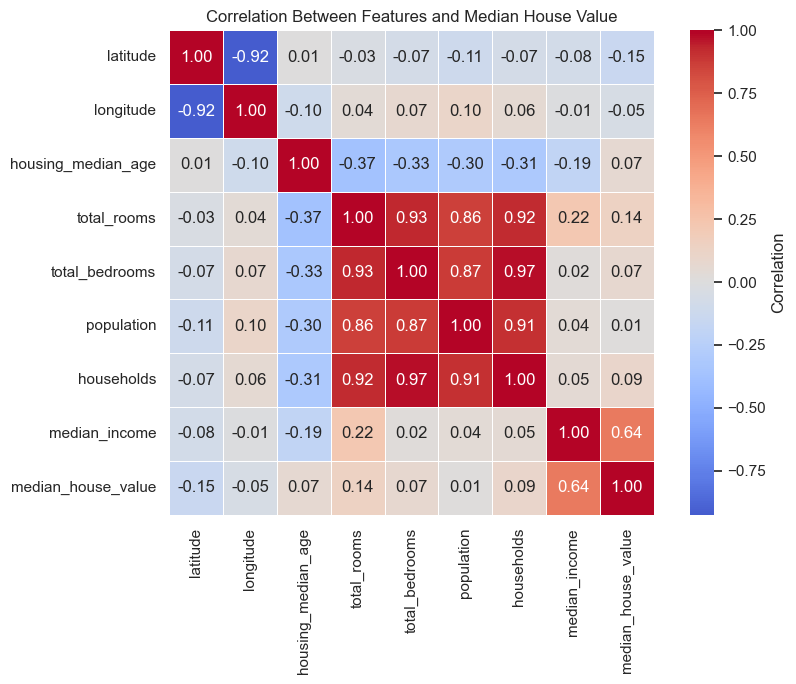

In [23]:
corrs = house_price_features + ['median_house_value']
df_corrs = df[corrs].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(df_corrs, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Features and Median House Value')
plt.tight_layout()
plt.show()

In [24]:
df_corrs['median_house_value'].drop('median_house_value').round(2).sort_values(key=abs, ascending=False)

median_income         0.64
latitude             -0.15
total_rooms           0.14
households            0.09
housing_median_age    0.07
total_bedrooms        0.07
longitude            -0.05
population            0.01
Name: median_house_value, dtype: float64

Features with high absolute correlation scores are key candidates for model training. I can see from the above that `median_income` has a strong positive correlation with `median_house_value` at 0.64.

In [25]:
df_corrs.loc[['total_rooms', 'total_bedrooms', 'population', 'households'], 'total_rooms'].round(2)

total_rooms       1.00
total_bedrooms    0.93
population        0.86
households        0.92
Name: total_rooms, dtype: float64

The features above show strong correlations with one another. Using them as raw inputs risks introducing multicollinearity into the model, which can lead to unstable coefficient estimates.

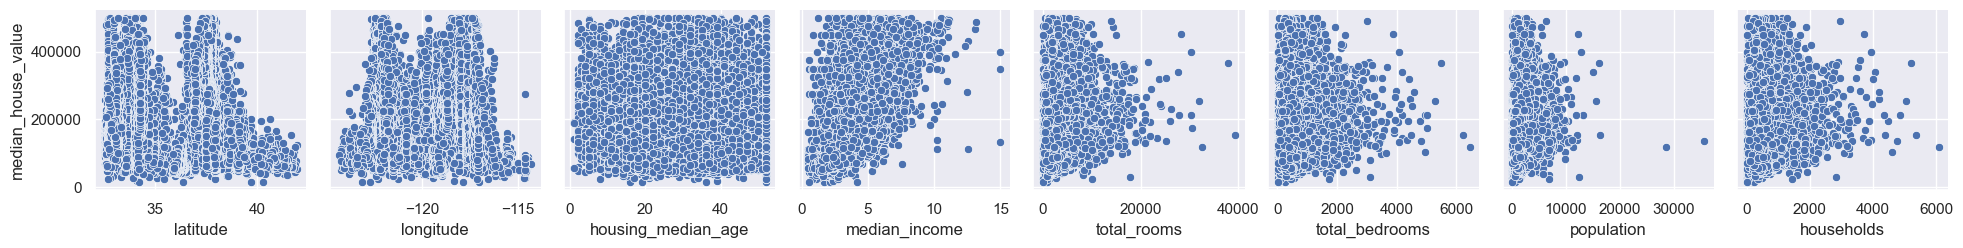

In [26]:
sns.pairplot(df, x_vars=['latitude', 'longitude', 'housing_median_age', 'median_income', 'total_rooms', 'total_bedrooms', 'population', 'households'],
             y_vars=['median_house_value'])
plt.show()

The pairplots above reinforce the earlier correlation results: `latitude` and `longitude` aren't good candidates for the linear regression model. Rather than varying linearly with median house value, they show non-linear, hotspot-driven patterns, as seen later.

<Axes: xlabel='latitude', ylabel='longitude'>

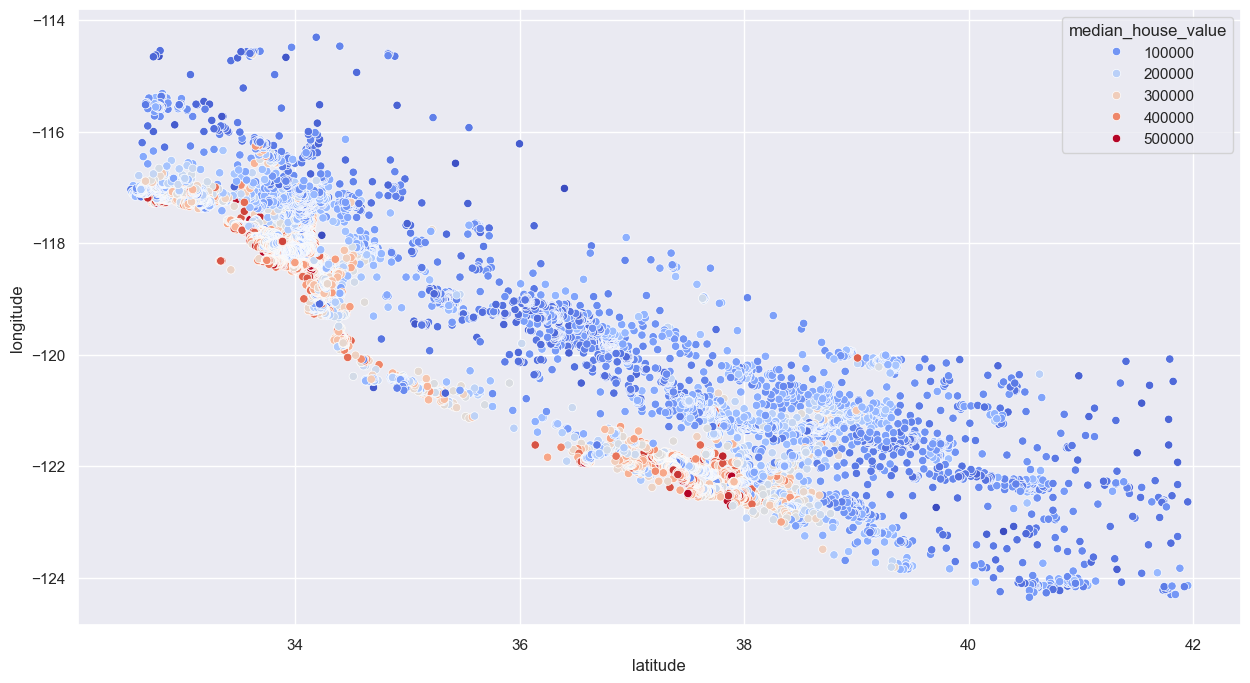

In [27]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude', y='longitude', data=df, hue='median_house_value', palette="coolwarm")

While lattitude and longitude don't have any correlation to median house value (-0.15 and -0.05 respectively), we can see from the scatterplot above that there are hotspots of expensive houses closer to the coast line in California, with median house prices getting cheaper the more inland you go. 

Bottom-left cluster (~latitude 33-34, longitude -118 to -119): the Los Angeles / greater LA basin area.

Middle-right cluster (~latitude 37-38, longitude -122): the San Francisco Bay Area.

## 6. Hot encoding the categorical variable

I one-hot encode `ocean_proximity` so the model can process this categorical feature numerically. (`<1H OCEAN`) category column is dropped to avoid redundant, perfectly correlated columns (the dummy variable trap).

In [28]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)

In [29]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [30]:
df[["ocean_proximity_INLAND", "ocean_proximity_ISLAND", "ocean_proximity_NEAR BAY", "ocean_proximity_NEAR OCEAN", "median_house_value"]].corr()['median_house_value'].round(2).drop('median_house_value').sort_values(ascending=False)

ocean_proximity_NEAR BAY      0.16
ocean_proximity_NEAR OCEAN    0.14
ocean_proximity_ISLAND        0.03
ocean_proximity_INLAND       -0.50
Name: median_house_value, dtype: float64

## 7. Feature engineering

From the correlation coefficient in cell 92, we can see that `total_rooms`, `total_bedrooms`, `population` and `households` are all strongly correlated to one another. These are potentially useful features in our model, however using several of them together would introduce multicollinearity among the features, making the model's coefficients less reliable.

To avoid this, we replace these four raw columns with two engineered features - `rooms_per_household` and `population_per_household` - derived from them.

These features also make more sense in the context of our model, as each row gives us a value for a block, not an individual household. We can't tell if high rooms or populations on their own mean anything for median house value without the number of households being in the denominator.

In [31]:
df['rooms_per_household'] = (df['total_rooms'] / df['households']).round(2)
df['population_per_household'] = (df['population'] / df['households']).round(2)

In [32]:
rooms_per_household_corr = df["rooms_per_household"].corr(df["median_house_value"])
population_per_household_corr = df["population_per_household"].corr(df["median_house_value"])
population_per_household_rooms_per_household_corr = df["population_per_household"].corr(df["rooms_per_household"])

print(f"The correlation for rooms per household to median house value is: {rooms_per_household_corr:.2f}")
print(f"The correlation for population per household to median house value is: {population_per_household_corr:.2f}")
print(f"The correlation for population per household to rooms per household is: {population_per_household_rooms_per_household_corr:.2f}")


The correlation for rooms per household to median house value is: 0.11
The correlation for population per household to median house value is: -0.02
The correlation for population per household to rooms per household is: -0.01


## 8. Building the linear regression model

In [33]:
from sklearn.model_selection import train_test_split

When choosing the features to use in my model, I considered different factors. 

`population_per_household` wasn't included as it had virtually no correlation to `median_house_value`, and `ocean_proximity_ISLAND` wasn't included either as there were only 5 houses tagged to this -  which isn't a big enough sample to build the model. 

In [ ]:
X = df[['median_income', 'rooms_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR OCEAN', 'ocean_proximity_NEAR BAY']]
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

I save the trained model to a file (`house_price_model.pkl`) using `joblib`, so it can be loaded elsewhere without needing to retrain it — in this case, by a separate Streamlit app that takes user inputs and returns a prediction.

In [35]:
import joblib
joblib.dump(lm, 'house_price_model.pkl')

['house_price_model.pkl']

In [46]:
predictions = lm.predict(X_test)
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=["Model coefficient"]).round(2)
print('Intercept:', round(lm.intercept_, 2))
coef_df

Intercept: 84712.56


,Model coefficient
median_income,35003.43
rooms_per_household,-51.37
ocean_proximity_INLAND,-72489.84
ocean_proximity_NEAR OCEAN,16157.72
ocean_proximity_NEAR BAY,14292.07


`median_income`: has the largest positive coefficient in our model. A coefficient of 35,003.43 shows that while holding every other feature constant, an increase in median income of $10,000 dollars (one unit), increases the median_house_value by $35,003.

`ocean_proximity_NEAR OCEAN` / `ocean_proximity_NEAR BAY`: shows modest positive effects relative to the baseline category (<1H OCEAN) — being near the ocean or bay adds some value, but far less than income does.

`ocean_proximity_INLAND`: strong negative effect relative to baseline (~-$72k) — inland houses are worth notably less than <1H OCEAN houses, holding other features constant.

`rooms_per_household`: Interestingly, this coefficient is negative, despite it's raw correlation coefficient with `median_house_value` being slightly positive (0.11). This is normally a sign for multicollinearity, so we first check for this between our model's features. We can do this using the Variation Inflation Factor (VIF) score. This measures how much the variance of an estimated regression coefficient is increased because of correlation with other predictor variables in a statistical model. A high VIF score of > 5 indicates high correlation, whereas a score of 1 indicates no correlation with any other variables.



In [37]:
X_const = add_constant(X)
VIF_scores = {}
for i in range(len(X_const.columns)):
    VIF_scores[X_const.columns[i]] = variance_inflation_factor(X_const.values, i).round(2)

pd.DataFrame.from_dict(VIF_scores, orient="index", columns=["VIF score"]).drop(index='const')

,VIF score
median_income,1.24
rooms_per_household,1.21
ocean_proximity_INLAND,1.33
ocean_proximity_NEAR OCEAN,1.13
ocean_proximity_NEAR BAY,1.11


A VIF score of 1.21 indicates that `rooms_per_household` is not meaningfully correlated with the other features in the model, ruling out multicollinearity as the cause of its negative coefficient.

Instead, this is explained by what the coefficient represents once `median_income` is controlled for. The raw correlation between `rooms_per_household` and median house value (0.11) is weakly positive, but this mixes two effects together: the part of the relationship that overlaps with median income, and the part that's independent of it. Once `median_income`'s coefficient absorbs the overlapping part, the leftover signal in `rooms_per_household` is negative — meaning that among areas with similar income, a higher rooms-per-household ratio is associated with lower house value, likely reflecting a location-premium effect (dense, high-value urban areas tend to have fewer rooms per household than spacious, lower-value inland areas).

## 9. Evaluating the linear regression model

In [38]:
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"The MSE is: {mse:.2f}")
print(f"The RMSE is: {rmse:.2f}")
print(f"The R2 value is: {r2:.2f}")

The MSE is: 4414786714.98
The RMSE is: 66443.86
The R2 value is: 0.55


The R-squared value of 0.55 means that the model can explain 55% of the variation in the dependent variable. The remaining 45% is mostly caused by other factors the model doesn't know about, as well as maybe some noise.

Text(0.5, 12.44444444444443, 'Residual')

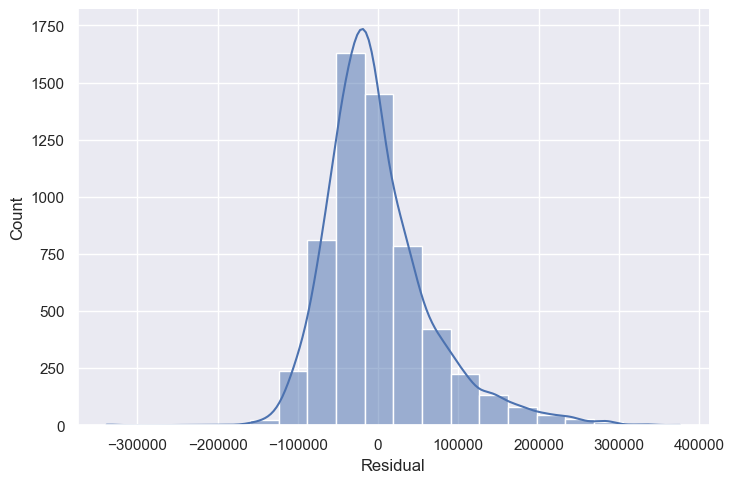

In [39]:
residuals = y_test - predictions
sns.displot(residuals, bins=20, kde=True, height=5, aspect=1.5)
plt.xlabel("Residual")

The residuals are roughly centered at zero but right-skewed, with a tail of large positive residuals. Since residual = actual − predicted, a positive residual means the model underpredicted — but this plot alone doesn't tell us *where* in the price range those underpredictions occur. That's explored further in the residuals-vs-actual plot below.

Text(0.5, 1.0, 'Distribution of Residuals Against Median House Value')

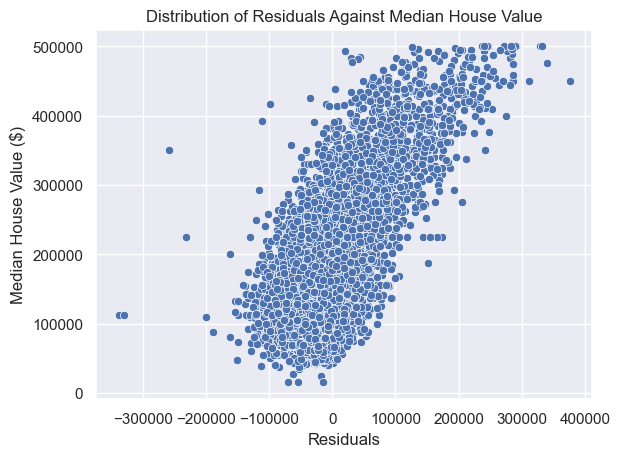

In [40]:
sns.scatterplot(x= residuals, y =y_test)
plt.xlabel("Residuals")
plt.ylabel("Median House Value ($)")
plt.title("Distribution of Residuals Against Median House Value")

Plotting residuals against actual median house value shows that residual spread widens as house value increases — residuals are tightly clustered near zero for lower-value houses, but become substantially larger and more variable at the higher end. This heteroscedasticity indicates the model's precision is not constant across the price range; it is considerably less precise for expensive houses than for cheaper ones.

Text(0.5, 1.0, 'Evaluation of The Linear Regression Model')

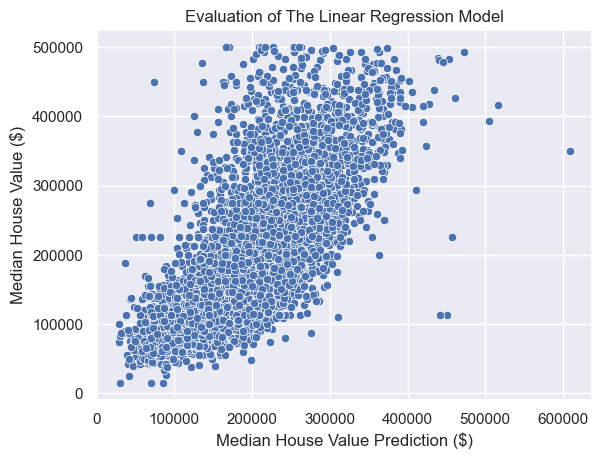

In [41]:
sns.scatterplot(x= predictions, y= y_test)
plt.xlabel("Median House Value Prediction ($)")
plt.ylabel("Median House Value ($)")
plt.title("Evaluation of The Linear Regression Model")

Plotting predictions against actual median house values, with an implied y = x line representing a perfect prediction, shows two patterns. First, the spread of points around this line widens as house value increases — points cluster tightly near the diagonal at lower values, but fan out substantially at the higher end, consistent with the heteroscedasticity seen in the residual plots. Second, in the upper range (roughly $400,000+), points cluster slightly to the top-left of the diagonal, indicating the model tends to underpredict the most expensive houses — the same pattern identified in the residuals-vs-actual analysis, now confirmed from a different angle.